# Hotel Revenue Forecasting Pipeline

**Enjoy Costa Rica — Revenue Analytics**

Pipeline completo de pronóstico de series temporales para la predicción de ingresos hoteleros.

## Estructura del Notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Setup & Configuración |
| 1 | Carga de Datos |
| 2 | Análisis Exploratorio (EDA) |
| 3 | Preprocesamiento & Feature Engineering (sin fuga de datos) |
| 4 | Modelos Estadísticos (Prophet, SARIMAX, ETS) |
| 5 | Modelos de ML (LightGBM, XGBoost, CatBoost) — evaluación recursiva multi-paso |
| 6 | Deep Learning (PatchTST; TimesFM excluido en Windows) |
| 7 | Comparación Final (incluye baseline Seasonal Naive) |
| 8 | Pronóstico Futuro (mejor modelo reentrenado con toda la historia) |
| 9 | Conclusiones & Advertencias Honestas |

> **Protocolo de evaluación**: todas las métricas del test son **multi-paso reales**
> (los modelos nunca ven los reales del test como entradas), en **dólares reales**,
> sobre la **misma serie** (portafolio agregado diario), con baseline de referencia.

---
## Section 0: Setup & Imports

**Buenas prácticas aplicadas:**
- **Reproducibilidad**: semilla global (`SEED=42`) y configuración centralizada en `config.yaml` — splits, horizontes e hiperparámetros viven en un solo lugar versionable, no como "números mágicos" dentro de las celdas.
- **Separación de responsabilidades**: la lógica vive en el paquete `src/forecasting/` (testeado con pytest, 25 tests); el notebook orquesta, visualiza y documenta — no duplica código.
- **Trazabilidad**: logging estructurado de cada componente (qué hizo cada módulo, con cuántos datos y en cuánto tiempo).

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Add src to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Load config
CONFIG_PATH = PROJECT_ROOT / 'config.yaml'
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Config loaded: {list(CONFIG.keys())}")

Project root: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 1.26.4, Pandas: 2.2.3
Config loaded: ['random_seed', 'log_level', 'data', 'preprocessing', 'models', 'evaluation', 'forecasting', 'visualization']


In [2]:
# Import forecasting modules
from src.forecasting.data import DataLoader
from src.forecasting.eda import EDAAnalyzer, EDAVisualizer
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.models.statistical import ProphetForecaster, SARIMAXForecaster, ETSForecaster
from src.forecasting.models.ml import LightGBMForecaster, XGBoostForecaster, CatBoostForecaster
from src.forecasting.models.dl import TimesFMForecaster, PatchTSTForecaster
from src.forecasting.evaluation import Evaluator, EvaluationVisualizer
from src.forecasting.forecasting.recursive import recursive_forecast
from src.forecasting.models.base import ForecastResult

print("All modules imported successfully!")

All modules imported successfully!


---
## Section 1: Data Loading

**Módulo `data/` — `DataLoader` + validación de esquema**

| Práctica | Justificación |
|---|---|
| Fuente SQL con `UNION ALL` (tabla operacional + financiera) y fallback CSV | Permite desarrollar y testear sin conexión sin cambiar nada del resto del pipeline |
| Validación de esquema al cargar (columnas requeridas, tipos, parseo de fechas) | *Fail fast*: un dato mal cargado se detecta aquí mismo, no en producción |
| Columnas NULL tipadas explícitamente (`cost_center`, `debit_amount`, `credit_amount`) | La tabla financiera trae columnas vacías; documentarlas evita sorpresas en el EDA |

**Diccionario mínimo de datos**: `date` (día), `hotel_id`, `revenue` (ingreso total) y `room_revenue` (ingreso por habitaciones). Opcionales de operación: `rooms_sold`, `available_rooms`, `occupancy_rate`, `adr` (tarifa media diaria), `revpar` (ingreso por habitación disponible).

In [3]:
# Load data — using sample data for offline development
# To use SQL: DataLoader(db_config={"host": "...", "database": "..."})
loader = DataLoader(csv_path=PROJECT_ROOT / 'data' / 'hotel_data.csv')

try:
    df = loader.load()
    print(f"Loaded {len(df)} rows from source.")
except FileNotFoundError:
    print("CSV not found. Generating synthetic sample data for development...")
    df = loader.load_sample(n_hotels=5, n_days=365*3, seed=SEED)
    # Save for future use
    (PROJECT_ROOT / 'data').mkdir(exist_ok=True)
    df.to_csv(PROJECT_ROOT / 'data' / 'hotel_data.csv', index=False)
    print(f"Generated and saved {len(df)} rows.")

print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Hotels: {df['hotel_id'].nunique()}")
df.head(10)

src.forecasting.data.loader - INFO - Loading data from CSV: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\data\hotel_data.csv


src.forecasting.data.loader - INFO - Loaded 5475 rows from CSV.


src.forecasting.data.schema - INFO - Schema validation: 13 columns checked, 4 warnings, 0 errors


src.forecasting.data.loader - INFO - INFO: Column 'rooms_sold' dtype is int64, expected ~float64.


src.forecasting.data.loader - INFO - INFO: Column 'available_rooms' dtype is int64, expected ~float64.


...

src.forecasting.data.loader - WARNING - WARNING: Column 'account_code' is entirely NULL (likely from financial table UNION).


src.forecasting.data.loader - WARNING - WARNING: Column 'debit_amount' is entirely NULL (likely from financial table UNION).


src.forecasting.data.loader - WARNING - WARNING: Column 'credit_amount' is entirely NULL (likely from financial table UNION).


Loaded 5475 rows from source.

Shape: (5475, 13)
Date range: 2023-08-28 00:00:00 to 2026-08-26 00:00:00
Hotels: 5


,date,hotel_id,revenue,room_revenue,rooms_sold,available_rooms,occupancy_rate,adr,revpar,cost_center,account_code,debit_amount,credit_amount
0,2023-08-28,HOTEL_001,169529.251105,122352.580580,31,150,0.451798,245.855800,164.170955,NaN,NaN,NaN,NaN
1,2023-08-29,HOTEL_001,200524.874947,115426.675255,110,150,0.647712,143.035664,189.014748,NaN,NaN,NaN,NaN
2,2023-08-30,HOTEL_001,211274.569701,150966.734497,90,150,0.524981,174.279414,59.572588,NaN,NaN,NaN,NaN
3,2023-08-31,HOTEL_001,208108.248938,140750.451319,77,150,0.816948,140.269415,195.604704,NaN,NaN,NaN,NaN
4,2023-09-01,HOTEL_001,167836.858949,118438.560663,118,150,0.656697,87.446640,73.143424,NaN,NaN,NaN,NaN
5,2023-09-02,HOTEL_001,159828.856755,111712.768002,45,150,0.932130,135.390311,105.568956,NaN,NaN,NaN,NaN
6,2023-09-03,HOTEL_001,166873.039501,98103.704043,80,150,0.661638,118.574589,150.472099,NaN,NaN,NaN,NaN
7,2023-09-04,HOTEL_001,190021.414374,136157.115612,36,150,0.785146,133.102329,174.838970,NaN,NaN,NaN,NaN
8,2023-09-05,HOTEL_001,203188.531291,127499.924759,136,150,0.775373,103.757922,79.986230,NaN,NaN,NaN,NaN
9,2023-09-06,HOTEL_001,204821.200353,144887.419312,57,150,0.765668,199.878114,167.109355,NaN,NaN,NaN,NaN


In [4]:
# Data schema overview
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Shape: {df.shape} ===")
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB ===")

=== Data Types ===
date               datetime64[ns]
hotel_id                   object
revenue                   float64
room_revenue              float64
rooms_sold                  int64
available_rooms             int64
occupancy_rate            float64
adr                       float64
revpar                    float64
cost_center               float64
account_code              float64
debit_amount              float64
credit_amount             float64
dtype: object

=== Shape: (5475, 13) ===

=== Missing Values ===
date                  0
hotel_id              0
revenue               0
room_revenue          0
rooms_sold            0
available_rooms       0
occupancy_rate        0
adr                   0
revpar                0
cost_center        5475
account_code       5475
debit_amount       5475
credit_amount      5475
dtype: int64

=== Memory Usage: 0.85 MB ===


---
## Section 2: Exploratory Data Analysis (EDA)

**Módulo `eda/` — EDA orientado a decisiones** (cada análisis responde una pregunta de modelado, no es decorativo):

| Análisis | Pregunta | Decisión que alimenta |
|---|---|---|
| Estadística descriptiva | ¿Escala y dispersión de los ingresos? | Umbral de error aceptable en $ para el negocio |
| Valores faltantes | ¿Hay huecos o columnas vacías? | Estrategia de imputación (ffill/interpolación) |
| Descomposición STL | ¿La serie = tendencia + estacionalidad + ruido? | Justifica modelos de componentes (Prophet/ETS) |
| Tests ADF / KPSS | ¿La serie es estacionaria? | Diferenciación que necesita SARIMA |
| ACF / PACF | ¿Qué rezagos predicen mejor? | Lags candidatos para features de ML |
| Estacionalidad semanal / anual | ¿Cuál es el periodo estacional? | `seasonal_periods=7`, Fourier anual de Prophet |
| Outliers (IQR, z-score) | ¿Días anómalos (cortesías, eventos)? | Flag/cap en preprocessing, no borrado ciego |
| Correlaciones | ¿`revenue` ≈ `room_revenue`? | Redundancias y targets alternativos |

> Buenas prácticas: el EDA guía el diseño de features y la elección de familia de modelos; los hallazgos quedan documentados para que cualquier decisión de modelado sea rastreable.

In [5]:
# Initialize EDA
eda = EDAAnalyzer(df, date_col='date', target_cols=['revenue', 'room_revenue'])
eda_viz = EDAVisualizer(eda)

# Descriptive statistics
desc_stats = eda.descriptive_statistics()
desc_stats

src.forecasting.eda.analyzer - INFO - Descriptive statistics computed for 2 columns.


,count,mean,median,std,min,q25,q50,q75,max,skewness,kurtosis,cv
column,,,,,,,,,,,,
revenue,5475,118840.427158,112050.166240,53767.984364,26904.086887,76129.669617,112050.166240,151261.992489,324061.313487,0.646217,-0.129765,0.452438
room_revenue,5475,77260.000595,71636.902213,35773.215245,15111.786902,49475.090592,71636.902213,98777.883604,214062.146779,0.710242,0.061293,0.463024


In [6]:
# Missing value analysis
missing = eda.missing_value_analysis()
print("Missing values:")
missing

src.forecasting.eda.analyzer - INFO - Found missing values in 4 columns.


Missing values:


,column,missing_count,missing_pct,dtype
0,cost_center,5475,100.0,float64
1,account_code,5475,100.0,float64
2,debit_amount,5475,100.0,float64
3,credit_amount,5475,100.0,float64


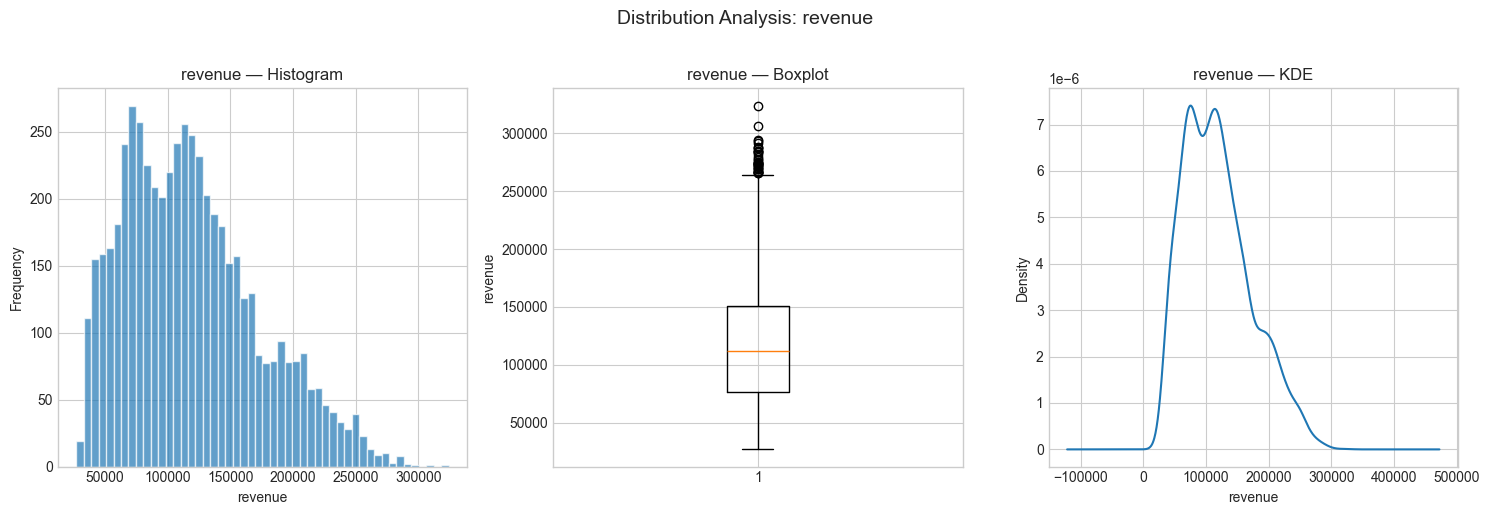

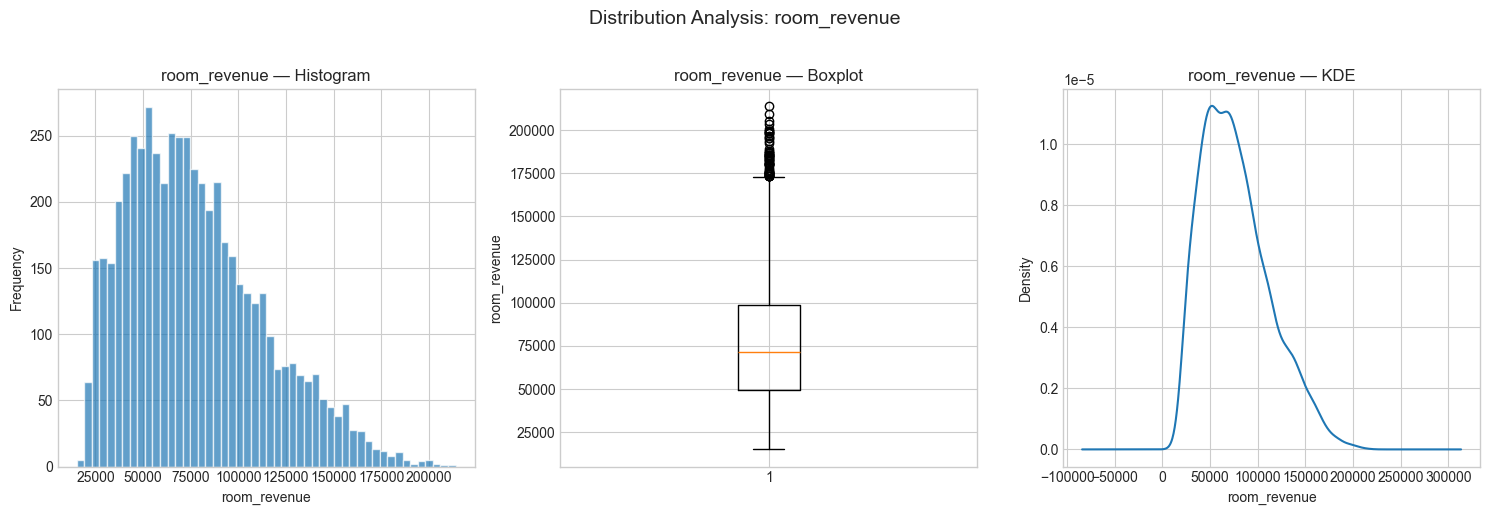

In [7]:
# Distribution plots
for col in ['revenue', 'room_revenue']:
    fig = eda_viz.plot_distributions(col)
    plt.show()

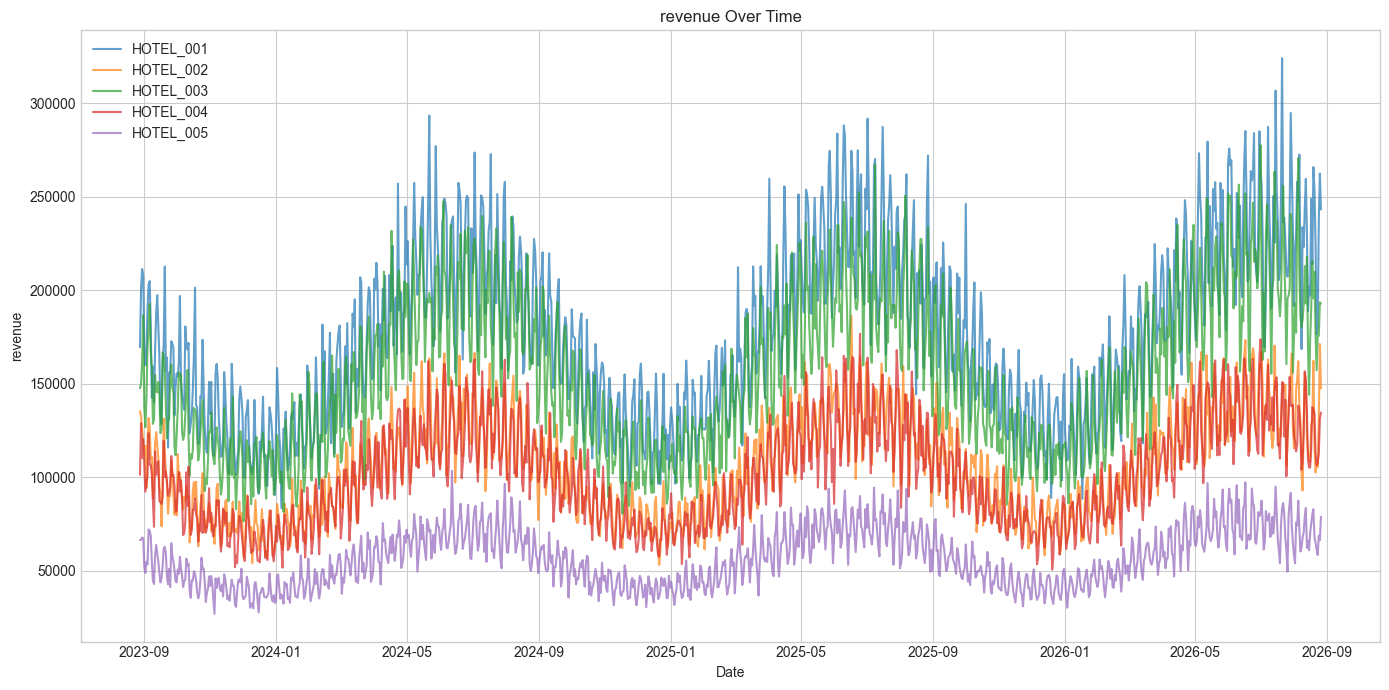

In [8]:
# Time series plot (per hotel)
fig = eda_viz.plot_time_series('revenue')
plt.show()

src.forecasting.eda.analyzer - INFO - Decomposition complete: model=additive, period=7


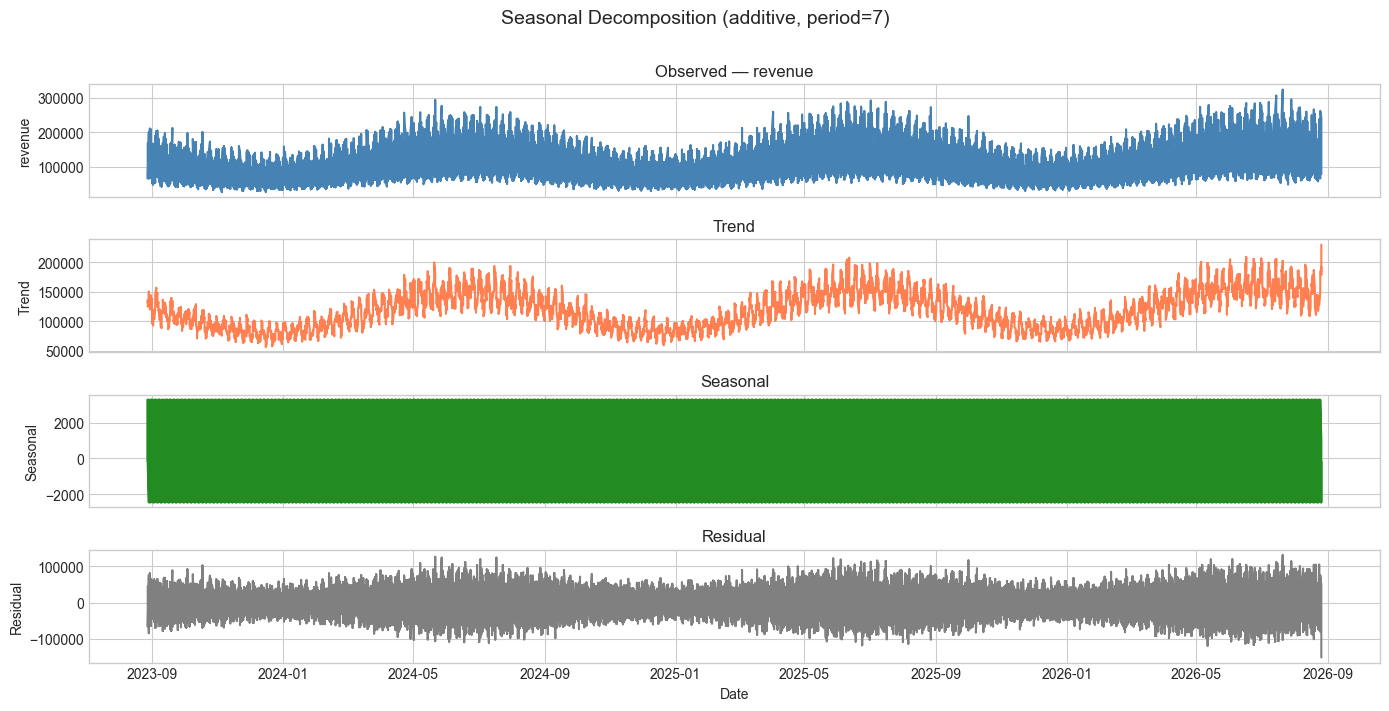

In [9]:
# Time series decomposition
decomp = eda.time_series_decomposition('revenue', period=7, model='additive')
fig = eda_viz.plot_decomposition(decomp, 'revenue')
plt.show()

In [10]:
# Stationarity tests
for col in ['revenue', 'room_revenue']:
    print(f"\n=== Stationarity Tests: {col} ===")
    results = eda.stationarity_tests(col)
    for r in results:
        print(f"  {r.test_name}: stat={r.statistic:.4f}, p={r.p_value:.4f} — {r.interpretation}")


=== Stationarity Tests: revenue ===


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\src\forecasting\eda\analyzer.py:263: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, p_val, n_lags, crit_vals = kpss(series, regression="c", nlags="auto")
src.forecasting.eda.analyzer - INFO - Augmented Dickey-Fuller: stat=-1.8333, p=0.3641 — Series is NOT stationary (fail to reject unit root null)


src.forecasting.eda.analyzer - INFO - KPSS: stat=1.9054, p=0.0100 — Series is NOT stationary (reject stationarity null)


  Augmented Dickey-Fuller: stat=-1.8333, p=0.3641 — Series is NOT stationary (fail to reject unit root null)
  KPSS: stat=1.9054, p=0.0100 — Series is NOT stationary (reject stationarity null)

=== Stationarity Tests: room_revenue ===


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\src\forecasting\eda\analyzer.py:263: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, p_val, n_lags, crit_vals = kpss(series, regression="c", nlags="auto")
src.forecasting.eda.analyzer - INFO - Augmented Dickey-Fuller: stat=-2.0467, p=0.2665 — Series is NOT stationary (fail to reject unit root null)


src.forecasting.eda.analyzer - INFO - KPSS: stat=1.8326, p=0.0100 — Series is NOT stationary (reject stationarity null)


  Augmented Dickey-Fuller: stat=-2.0467, p=0.2665 — Series is NOT stationary (fail to reject unit root null)
  KPSS: stat=1.8326, p=0.0100 — Series is NOT stationary (reject stationarity null)


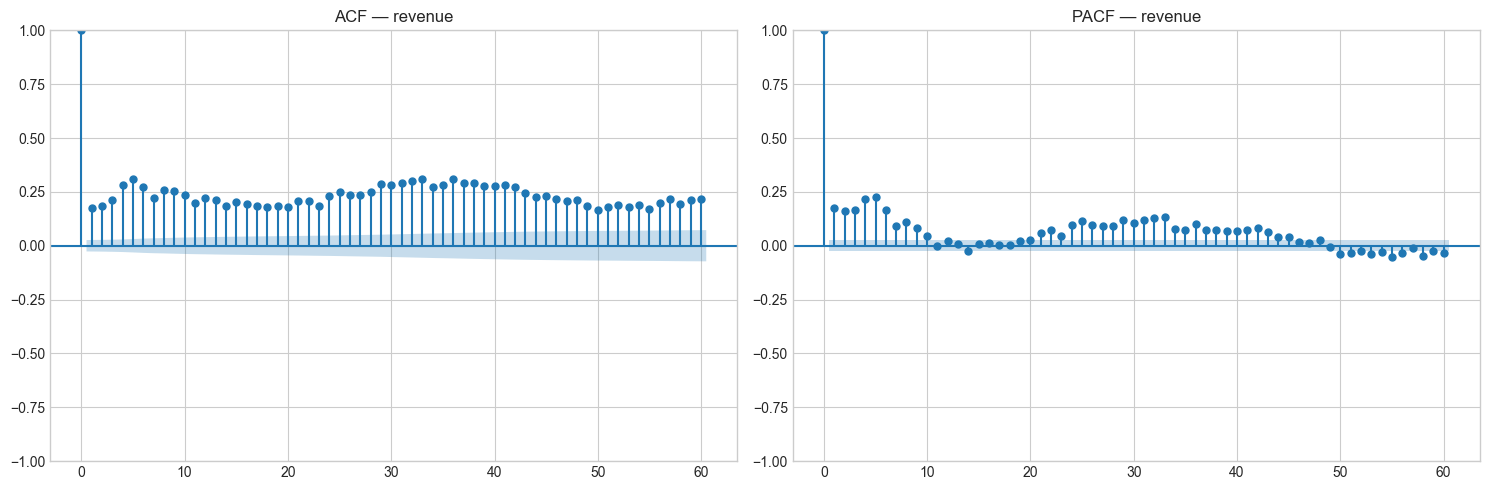

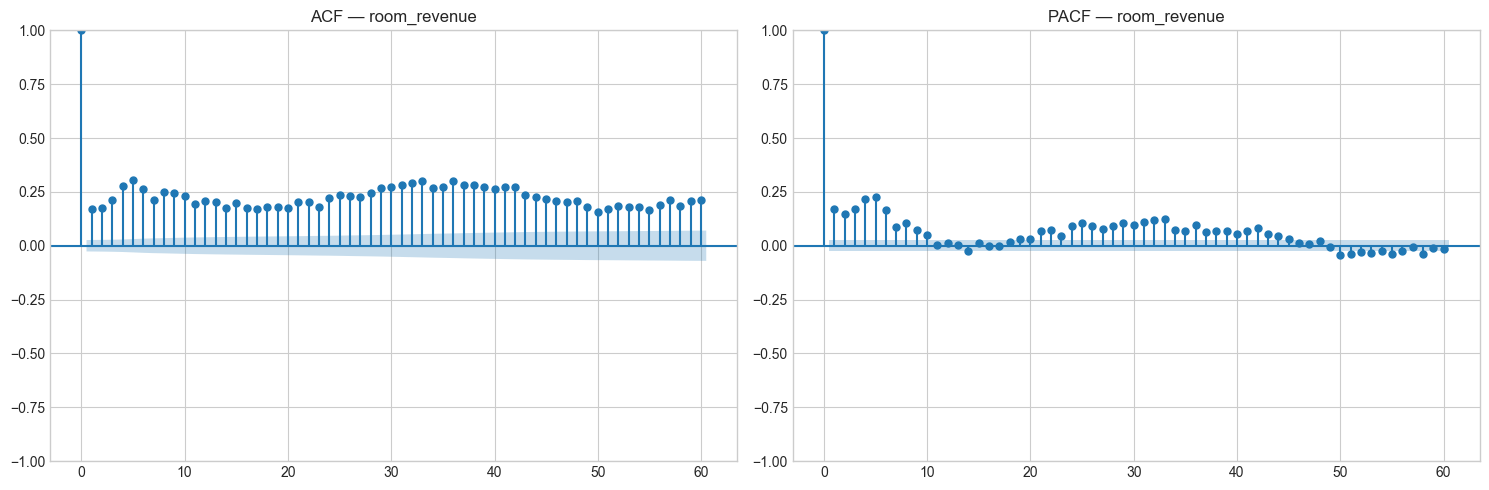

In [11]:
# ACF/PACF
for col in ['revenue', 'room_revenue']:
    fig = eda_viz.plot_acf_pacf(col, nlags=60)
    plt.show()

In [12]:
# Seasonality detection
for col in ['revenue', 'room_revenue']:
    print(f"\n=== Seasonality: {col} ===")
    seasonality = eda.seasonality_detection(col)
    for s in seasonality:
        print(f"  {s.pattern}: strength={s.strength:.3f}, p={s.p_value:.4f}")

src.forecasting.eda.analyzer - INFO - Seasonality — weekly: strength=0.010, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — monthly: strength=0.027, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — yearly: strength=0.014, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — weekly: strength=0.010, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — monthly: strength=0.026, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — yearly: strength=0.013, p=0.0000



=== Seasonality: revenue ===
  weekly: strength=0.010, p=0.0000
  monthly: strength=0.027, p=0.0000
  yearly: strength=0.014, p=0.0000

=== Seasonality: room_revenue ===
  weekly: strength=0.010, p=0.0000
  monthly: strength=0.026, p=0.0000
  yearly: strength=0.013, p=0.0000


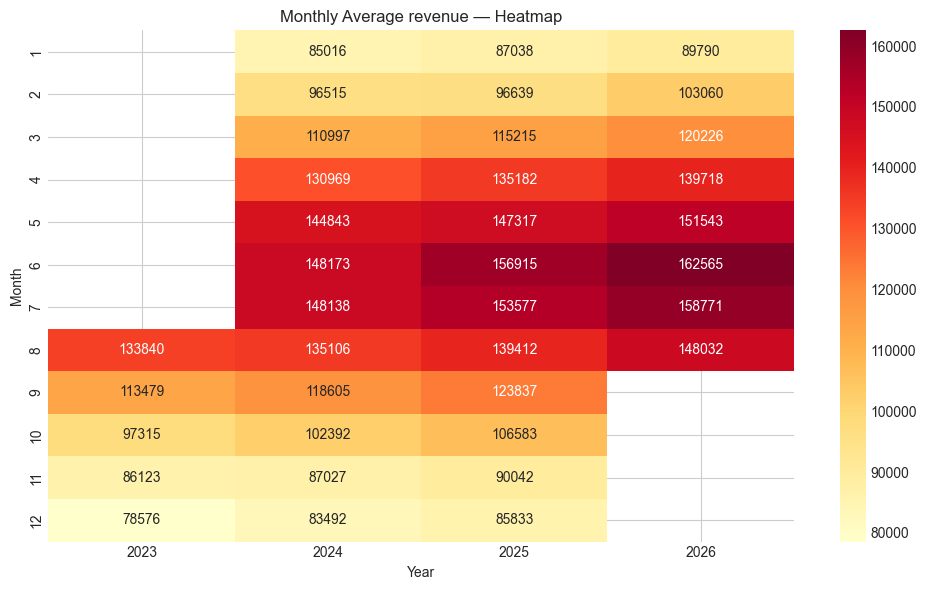

In [13]:
# Seasonal heatmap
fig = eda_viz.plot_seasonal_heatmap('revenue')
plt.show()

src.forecasting.eda.analyzer - INFO - Outlier detection (iqr): 35 outliers (0.64%)


Outliers: 35 (0.64%)


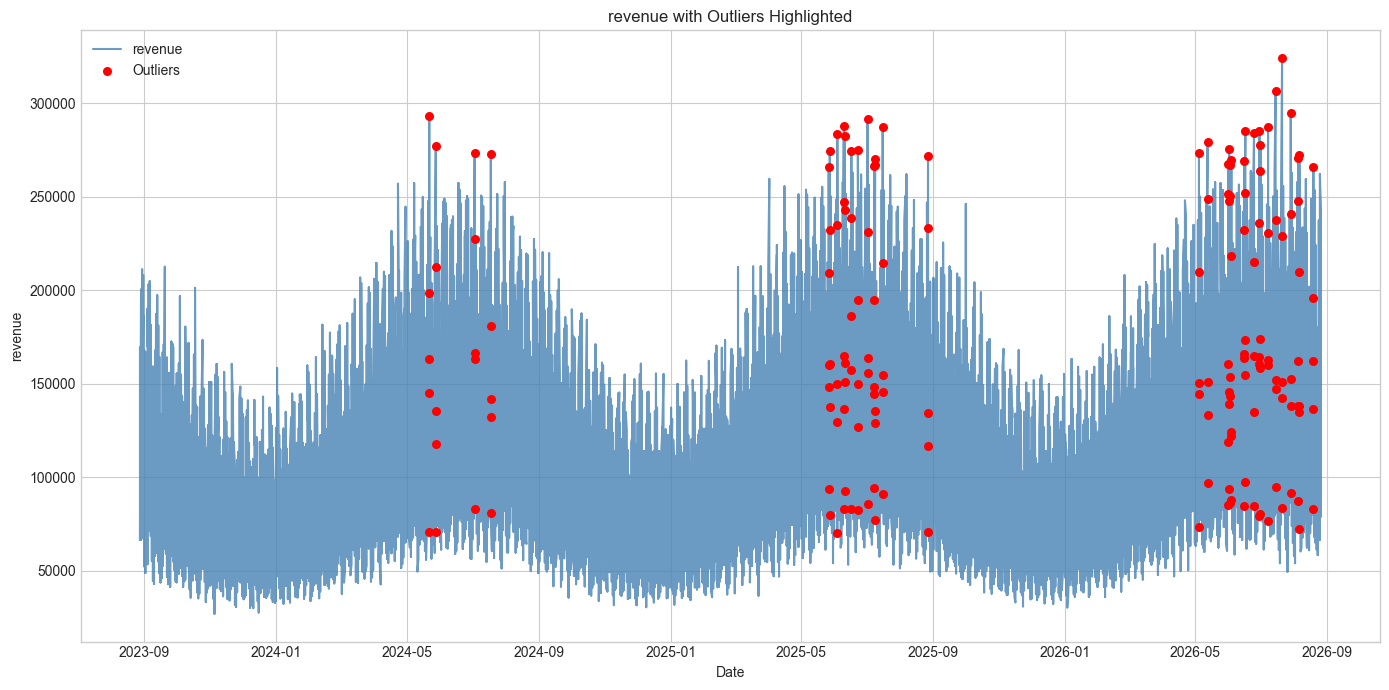

In [14]:
# Outlier detection
outlier_result = eda.outlier_detection('revenue', method='iqr', threshold=1.5)
print(f"Outliers: {outlier_result.n_outliers} ({outlier_result.outlier_pct}%)")
fig = eda_viz.plot_outliers('revenue', outlier_indices=outlier_result.outlier_indices)
plt.show()

src.forecasting.eda.analyzer - INFO - Correlation matrix computed (pearson) for 2 columns.


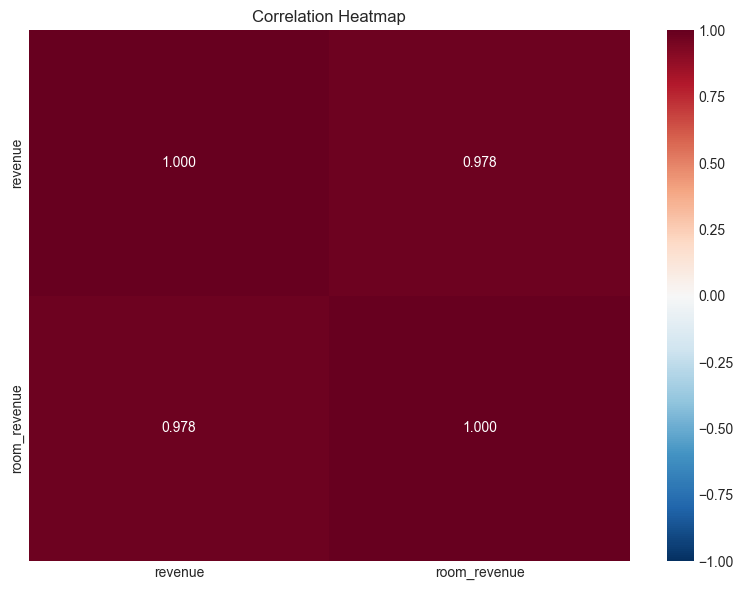

In [15]:
# Correlation analysis
corr = eda.correlation_analysis()
fig = eda_viz.plot_correlation_heatmap(corr)
plt.show()

---
## Section 3: Preprocessing & Feature Engineering

**Módulo `preprocessing/` — diseño anti-fuga (leakage-safe)**

**Protocolo de números honestos:**
- El target **NO se escala** → todas las métricas quedan en dólares reales.
- Lags/rollings se calculan sobre la serie cronológica completa **antes** del split: cada feature en `t` usa solo datos de `t-1` o anteriores (los lags nunca miran el futuro).
- Bounds de outliers se aprenden **solo del train** y se aplican a todos los splits.
- Evaluación del test: **recursiva multi-paso** — las predicciones (no los reales) alimentan los lags de los modelos ML.

**Las features son "memoria + contexto":**
- *Memoria del negocio*: `revenue_lag_{1,7,14,30,365}` + rollings de 7/14/30/90 días (nivel reciente y volatilidad). El `shift(1)` garantiza que cada ventana termina *antes* del día que se predice.
- *Contexto calendario*: día de semana, mes, flags de inicio/fin de mes y codificación seno/coseno (los ciclos no "saltan" entre diciembre y enero).
- *Contexto tico*: festivos de Costa Rica + ventanas pre/post festivo + días hasta el próximo festivo.
- *Control*: flags de outlier (`revenue_outlier`) aprendidas del train; en los días futuros se asumen 0.

**Split temporal 70/15/15 con gap de 7 días**: el corte es siempre por fecha, jamás aleatorio; el gap evita solapamiento de ventanas de features entre train y val/test.

In [16]:
# ------------------------------------------------------------------
# HONEST EVALUATION PROTOCOL (applies to every model below)
#   1. All models are evaluated on the SAME series: daily portfolio revenue
#      (sum across hotels) -> comparable metrics in real dollars.
#   2. Every test prediction is MULTI-STEP: models only use information
#      available before the test window starts.
#   3. ML models are evaluated with RECURSIVE forecasting: their own
#      predictions are fed back as lag inputs (test actuals are NEVER inputs).
#   4. A Seasonal Naive baseline is included: a model must beat it to be useful.
# ------------------------------------------------------------------

# Portfolio aggregation: one daily series
df_agg = (
    df.assign(date=pd.to_datetime(df["date"]))
      .groupby("date", as_index=False)[["revenue", "room_revenue"]]
      .sum()
      .sort_values("date")
      .reset_index(drop=True)
)
print(f"Aggregate series: {len(df_agg)} days | {df_agg['date'].min().date()} -> {df_agg['date'].max().date()}")

pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG["preprocessing"]["missing_values"]["strategy"],
    outlier_method=CONFIG["preprocessing"]["outliers"]["method"],
    outlier_action=CONFIG["preprocessing"]["outliers"]["action"],
    feature_config=CONFIG["preprocessing"]["features"],
    split_config=CONFIG["preprocessing"]["split"],
    scale_method=None,  # NO scaling: targets stay in real $ -> honest metrics
)

split_result, train_feat, val_feat, test_feat = pipeline.run(df_agg, date_col="date")

print(f"Train: {len(train_feat)}d | Val: {len(val_feat)}d | Test: {len(test_feat)}d | gap={split_result.gap_days}d")
print(f"train_end={split_result.train_end.date()}  val_end={split_result.val_end.date()}")

target_col = "revenue"
keep = ["date", target_col, "room_revenue"]
train_df = train_feat[keep].copy()
val_df = val_feat[keep].copy()
test_df = test_feat[keep].copy()

test_start = test_df["date"].min()
actuals_test = test_df[target_col].values
test_dates = pd.to_datetime(test_df["date"])

# ALL observations strictly before the test window (contiguous calendar series:
# the gap days are real observed data, never future information)
history_eval = df_agg.loc[df_agg["date"] < test_start, ["date", target_col]].reset_index(drop=True)
full_history = df_agg[["date", target_col, "room_revenue"]].copy()  # all observed data

print(f"History available at test time: {len(history_eval)} days (ends {history_eval['date'].max().date()})")

src.forecasting.preprocessing.splitter - INFO - Temporal split: train=766, val=157, test=158 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-10-01, val_end=2026-03-14


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 67 columns


Aggregate series: 1095 days | 2023-08-28 -> 2026-08-26


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=766, val=157, test=158 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-10-01, val_end=2026-03-14


src.forecasting.preprocessing.pipeline - INFO - Pipeline complete: train=766 rows/73 cols, val=157, test=158


Train: 766d | Val: 157d | Test: 158d | gap=7d
train_end=2025-10-01  val_end=2026-03-14
History available at test time: 937 days (ends 2026-03-21)


In [17]:
# Show engineered features
feature_cols_all = [
    c for c in train_feat.columns
    if c not in ["date", "hotel_id", target_col, "room_revenue"]
]
print(f"Engineered features ({len(feature_cols_all)}):")
for i, col in enumerate(feature_cols_all, 1):
    print(f"  {i:2d}. {col}")

Engineered features (70):
   1. year
   2. quarter
   3. month
   4. week
   5. day
   6. dayofweek
   7. dayofyear
   8. is_weekend
   9. is_month_start
  10. is_month_end
  11. is_quarter_start
  12. is_quarter_end
  13. dayofweek_sin
  14. dayofweek_cos
  15. dayofyear_sin
  16. dayofyear_cos
  17. month_sin
  18. month_cos
  19. revenue_lag_1
  20. revenue_lag_7
  21. revenue_lag_14
  22. revenue_lag_30
  23. revenue_lag_365
  24. room_revenue_lag_1
  25. room_revenue_lag_7
  26. room_revenue_lag_14
  27. room_revenue_lag_30
  28. room_revenue_lag_365
  29. revenue_rmean_7
  30. revenue_rstd_7
  31. revenue_rmin_7
  32. revenue_rmax_7
  33. revenue_rmean_14
  34. revenue_rstd_14
  35. revenue_rmin_14
  36. revenue_rmax_14
  37. revenue_rmean_30
  38. revenue_rstd_30
  39. revenue_rmin_30
  40. revenue_rmax_30
  41. revenue_rmean_90
  42. revenue_rstd_90
  43. revenue_rmin_90
  44. revenue_rmax_90
  45. room_revenue_rmean_7
  46. room_revenue_rstd_7
  47. room_revenue_rmin_7
  48. r

---
## Section 4: Statistical Models

**Módulo `models/statistical/` — modelos de estructura explícita**

**Buenas prácticas comunes**: se entrenan con **toda la historia previa al test** (serie continua, sin huecos) y se evalúan con predicciones **multi-paso alineadas por fecha** — exactamente el escenario de producción.

| Modelo | Qué es | Por qué funciona (o no) aquí |
|---|---|---|
| **Prophet** | Descomposición aditiva: tendencia flexible (changepoints) + estacionalidad semanal/anual (series de Fourier) + efecto de festivos de Costa Rica | Ideal para horizontes largos: proyecta componentes globales de un solo tirón, sin depender del valor de "ayer" |
| **SARIMAX** | ARIMA estacional: hoy explicado por su propio pasado reciente + patrón estacional; `auto_arima` elige los órdenes por AIC | Fuerte en horizontes de días; en 158 días sin componente estacional seleccionada, la deriva lo hunde (se reporta honestamente) |
| **ETS (Holt-Winters)** | Suavizado exponencial con nivel + tendencia amortiguada + patrón semanal; selección automática por AIC | Robusto y parsimonioso; captura bien el nivel pero no cambios de ritmo |
| **SeasonalNaive** | Repite la última semana observada, cíclicamente | **Disciplina de baseline**: cualquier modelo que no le gane a esto, no aporta valor |

In [18]:
# Statistical models see exactly the same information the ML models see:
# every observed day strictly before the test window.
train_val_df = history_eval.copy()
print(f"Statistical training window: {len(train_val_df)} days, ends {train_val_df['date'].max().date()}")

Statistical training window: 937 days, ends 2026-03-21


In [19]:
# --- Prophet ---
print("Training Prophet on the full pre-test history...")
prophet = ProphetForecaster(
    changepoint_prior_scale=CONFIG["models"]["statistical"]["prophet"]["changepoint_prior_scale"],
    seasonality_prior_scale=CONFIG["models"]["statistical"]["prophet"]["seasonality_prior_scale"],
)
prophet.fit(train_val_df, target_col=target_col, date_col="date")
prophet_result = prophet.predict(test_df, target_col=target_col, date_col="date")
print(f"Prophet: {len(prophet_result.predictions)} multi-step predictions")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - Adding TBB (C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\prophet\stan_model\cmdstan-2.33.1\stan\lib\stan_math\lib\tbb) to PATH


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmp602wog5n\zbgs6nfi.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmp602wog5n\ljdin7sb.json


Training Prophet on the full pre-test history...


...

cmdstanpy - INFO - Chain [1] start processing


14:29:00 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.25 seconds on 937 rows.


Prophet: 158 multi-step predictions


In [20]:
# --- SARIMAX ---
print("Training SARIMAX (auto_arima, weekly seasonality)...")
sarimax = SARIMAXForecaster(
    seasonal_periods=CONFIG["models"]["statistical"]["sarimax"]["seasonal_periods"],
    stepwise=CONFIG["models"]["statistical"]["sarimax"]["stepwise"],
)
sarimax.fit(train_val_df, target_col=target_col, date_col="date")
print(f"  order={sarimax._order}, seasonal_order={sarimax._seasonal_order}")
sarimax_result = sarimax.predict(test_df, target_col=target_col, date_col="date")
print(f"SARIMAX: {len(sarimax_result.predictions)} date-aligned multi-step predictions")

Training SARIMAX (auto_arima, weekly seasonality)...


src.forecasting.models.statistical.sarimax_model - INFO - SARIMAX fitted in 57.74 sec: order=(3, 1, 3), seasonal_order=(0, 0, 0, 7)


  order=(3, 1, 3), seasonal_order=(0, 0, 0, 7)
SARIMAX: 158 date-aligned multi-step predictions


In [21]:
# --- ETS (Holt-Winters) ---
print("Training ETS (auto selection by AIC)...")
ets = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
ets.fit(train_val_df, target_col=target_col, date_col="date")
print(f"  selected: {ets._model_params}")
ets_result = ets.predict(test_df, target_col=target_col, date_col="date")
print(f"ETS: {len(ets_result.predictions)} date-aligned multi-step predictions")

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\ba

Training ETS (auto selection by AIC)...


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


src.forecasting.models.statistical.ets_model - INFO - ETS fitted in 1.21 sec: params={'trend': 'mul', 'seasonal': 'mul', 'damped_trend': True, 'aic': 18881.287562129968}, AIC=18881.29


  selected: {'trend': 'mul', 'seasonal': 'mul', 'damped_trend': True, 'aic': 18881.287562129968}
ETS: 158 date-aligned multi-step predictions


SeasonalNaive: 158 predictions (last observed week cycled)


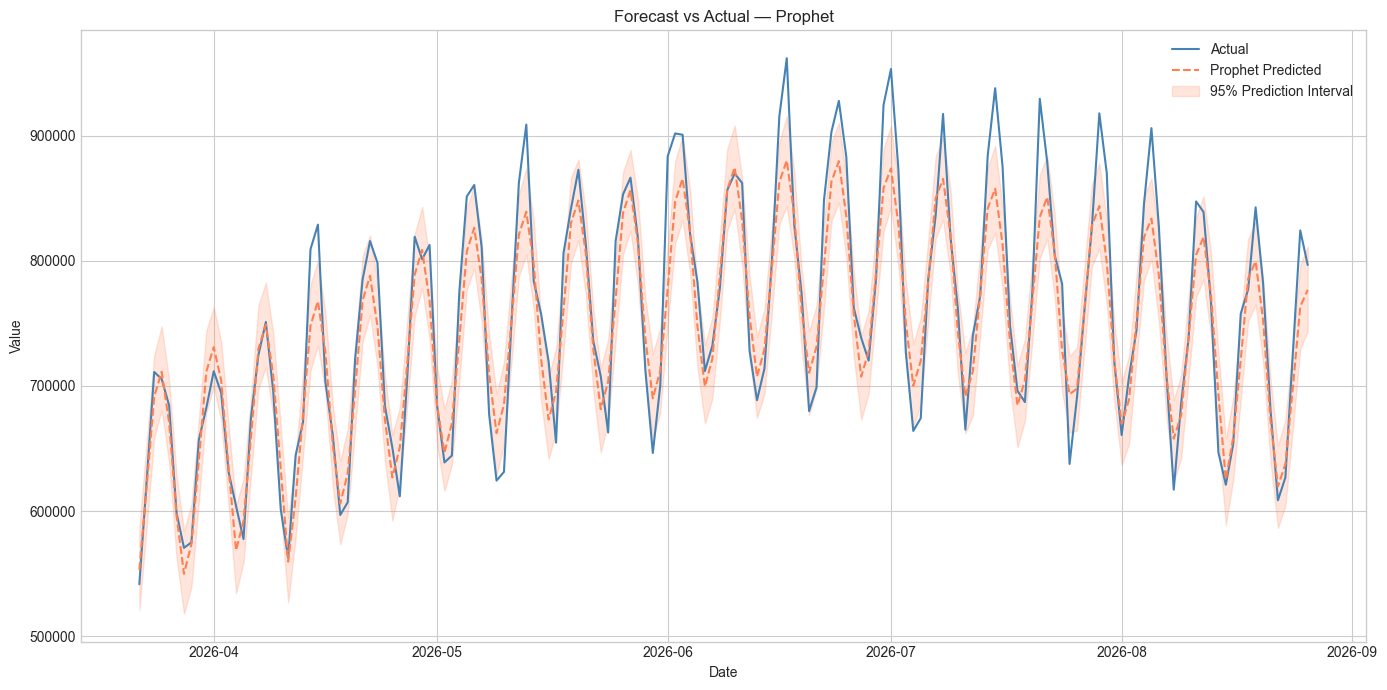

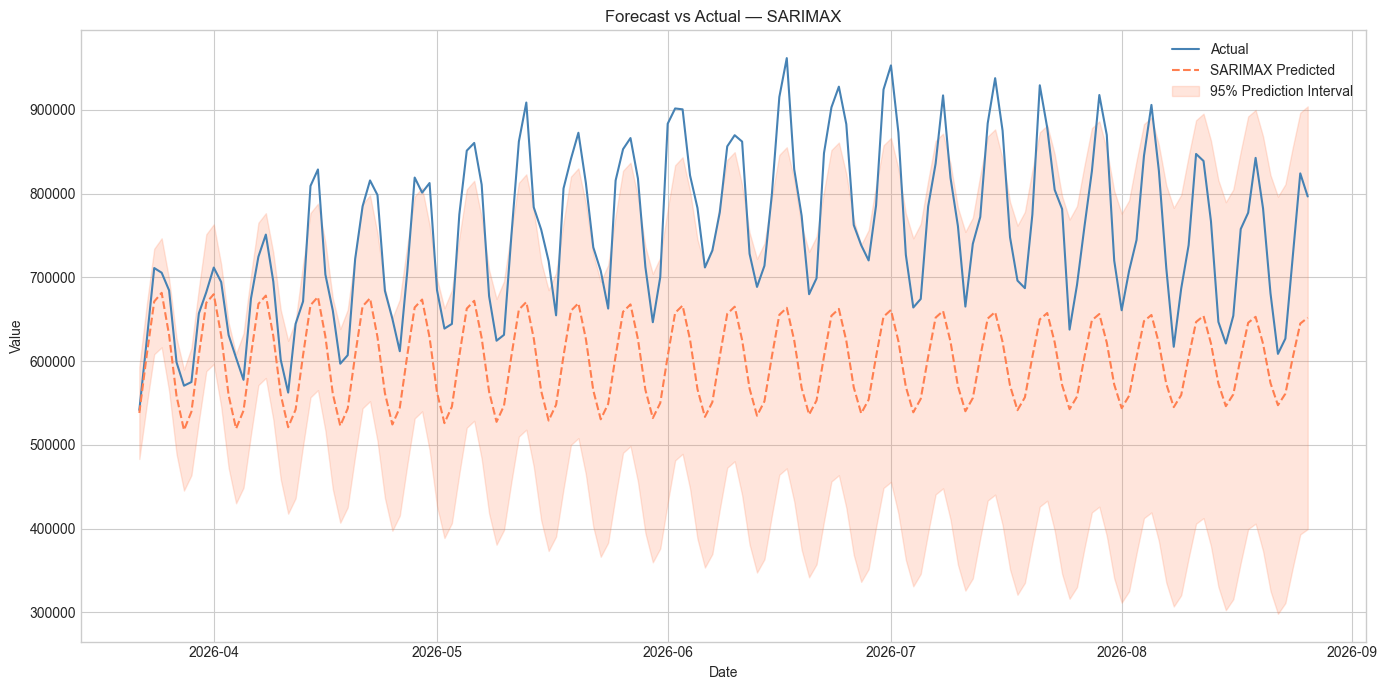

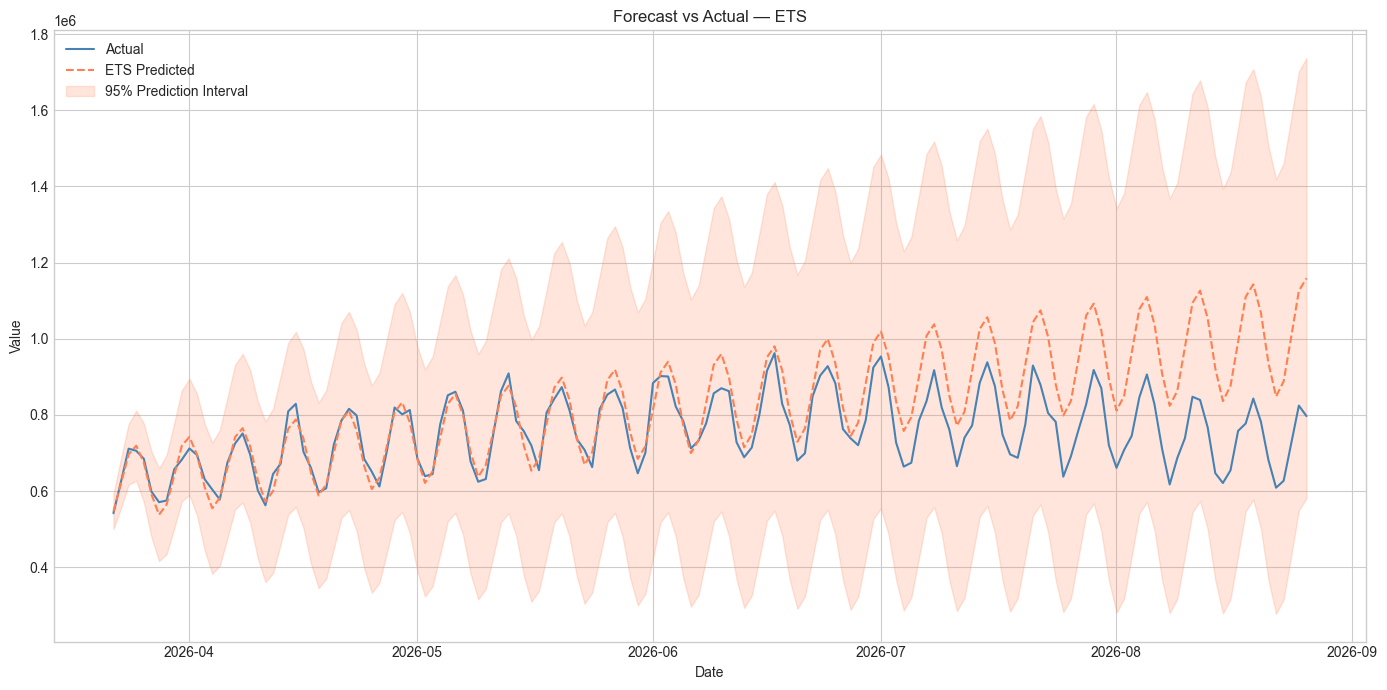

In [22]:
# --- Seasonal Naive baseline ---
# The reference any serious model must beat: repeat the last observed week.
last_week = history_eval[target_col].values[-7:]
naive_preds = np.array([last_week[i % 7] for i in range(len(test_df))])
print(f"SeasonalNaive: {len(naive_preds)} predictions (last observed week cycled)")

# Visualize statistical model forecasts
eval_viz = EvaluationVisualizer()
for name, result in [("Prophet", prophet_result), ("SARIMAX", sarimax_result), ("ETS", ets_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name, lower_bound=result.lower_bound, upper_bound=result.upper_bound,
    )
    plt.show()

---
## Section 5: Machine Learning Models

**Módulo `models/ml/` — Gradient Boosting (LightGBM, XGBoost, CatBoost)**

**Por qué boosting**: cientos de árboles pequeños donde cada uno corrige el error del anterior; capturan interacciones ("¿es viernes *y* fin de mes *y* víspera de festivo?") que los modelos aditivos no ven.

**Protocolo honesto en 3 pasos por modelo** — la clave de las métricas reales:
1. **Fit en train + early stopping en val**: las iteraciones óptimas se eligen con datos que el modelo no usa para entrenar.
2. **Refit en TODA la historia pre-test** con el nº de iteraciones ya fijado (no se re-tunea nada mirando el test).
3. **Predicción recursiva del test**: cada predicción se realimenta como lag para el día siguiente — los reales del test jamás son entradas. Sin esto, las métricas de árboles serían falsamente brillantes (efecto "conocer el ayer").

**Decisiones de diseño:**
- Features derivadas de `room_revenue` **excluidas**: su valor futuro es desconocido; usarlas obligaría a inventar entradas fantasma durante el pronóstico.
- Early stopping = regularización: corta el aprendizaje antes de memorizar ruido.
- Sin escalado: los árboles no lo necesitan y las métricas quedan en dólares.

In [23]:
# ML features: calendar/cyclical/lag/rolling/expanding + holiday flags.
# room_revenue-derived features are EXCLUDED (their future values are unknown).
drop_cols = ["date", "hotel_id", target_col, "room_revenue"]
feature_cols_ml = [
    c for c in train_feat.columns
    if c not in drop_cols and not c.startswith("room_revenue")
]
print(f"ML features ({len(feature_cols_ml)}):")
print(feature_cols_ml)

ML features (46):
['year', 'quarter', 'month', 'week', 'day', 'dayofweek', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30', 'revenue_lag_365', 'revenue_rmean_7', 'revenue_rstd_7', 'revenue_rmin_7', 'revenue_rmax_7', 'revenue_rmean_14', 'revenue_rstd_14', 'revenue_rmin_14', 'revenue_rmax_14', 'revenue_rmean_30', 'revenue_rstd_30', 'revenue_rmin_30', 'revenue_rmax_30', 'revenue_rmean_90', 'revenue_rstd_90', 'revenue_rmin_90', 'revenue_rmax_90', 'revenue_emean', 'revenue_estd', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'days_to_holiday', 'revenue_outlier']


In [24]:
def fit_gbm_honest(model_obj, name):
    """3-step honest GBM protocol: ES on val -> refit pre-test history -> recursive test forecast."""
    print(f"Training {name} (early stopping on val)...")
    model_obj.fit(train_feat, target_col=target_col, date_col="date",
                  feature_cols=feature_cols_ml, val_df=val_feat)
    print(f"  best_iteration={model_obj.best_iteration()}")

    # Refit on ALL pre-test data with the fixed iteration count
    hist_feat = pipeline.feature_engineer.transform(history_eval)
    hist_feat = pipeline.holiday_engineer.transform(hist_feat)
    hist_feat = pipeline.outlier_handler.transform(hist_feat)
    model_obj.final_refit(hist_feat, target_col=target_col, date_col="date",
                          feature_cols=feature_cols_ml)

    # Recursive multi-step forecast: predictions feed back as lags
    preds = recursive_forecast(
        model_obj, history_eval, test_dates,
        target_col=target_col, date_col="date",
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
    )
    print(f"  {name}: {len(preds)} recursive multi-step predictions")
    return preds

lgbm_params = {**LightGBMForecaster().params, **CONFIG["models"]["ml"]["lightgbm"]}
for k in ("early_stopping_rounds", "categorical_features"):
    lgbm_params.pop(k, None)
lgbm_params["n_estimators"] = 1000

lgbm = LightGBMForecaster(params=lgbm_params, early_stopping_rounds=50)
lgbm_preds = fit_gbm_honest(lgbm, "LightGBM")

Training LightGBM (early stopping on val)...


src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.30 sec, best iteration: 99


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


  best_iteration=99


...

src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps


  LightGBM: 158 recursive multi-step predictions


In [25]:
# --- XGBoost ---
xgb_params = {**XGBoostForecaster().params, **CONFIG["models"]["ml"]["xgboost"]}
xgb_params.pop("early_stopping_rounds", None)
xgb_params["n_estimators"] = 1000

xgb = XGBoostForecaster(params=xgb_params, early_stopping_rounds=50)
xgb_preds = fit_gbm_honest(xgb, "XGBoost")

Training XGBoost (early stopping on val)...


src.forecasting.models.ml.xgb_model - INFO - XGBoost fitted in 0.59 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


  best_iteration=95


...

src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps


  XGBoost: 158 recursive multi-step predictions


In [26]:
# --- CatBoost ---
cat_params = {**CatBoostForecaster().params, **CONFIG["models"]["ml"]["catboost"]}
for k in ("early_stopping_rounds", "cat_features"):
    cat_params.pop(k, None)
cat_params["iterations"] = 1000

cat = CatBoostForecaster(params=cat_params, early_stopping_rounds=50)
cat_preds = fit_gbm_honest(cat, "CatBoost")

Training CatBoost (early stopping on val)...


src.forecasting.models.ml.catboost_model - INFO - CatBoost fitted in 0.87 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


  best_iteration=250


...

src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 43 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps


  CatBoost: 158 recursive multi-step predictions


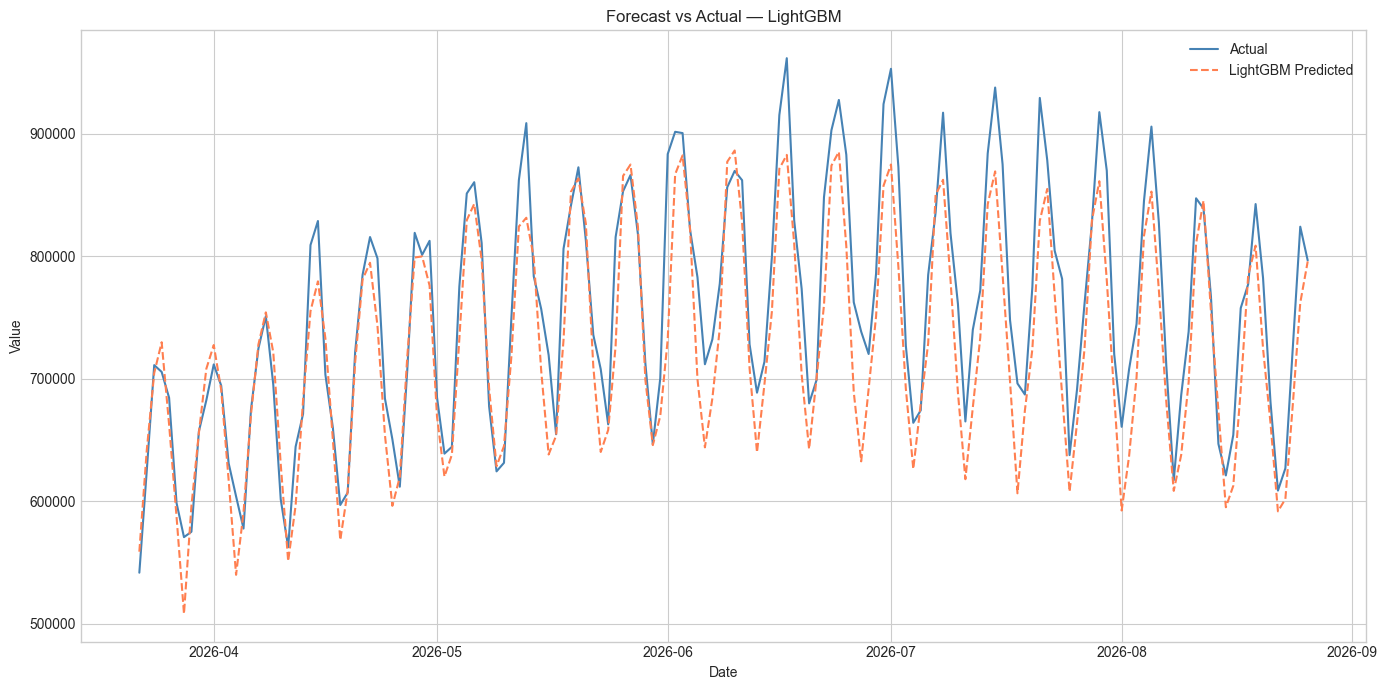

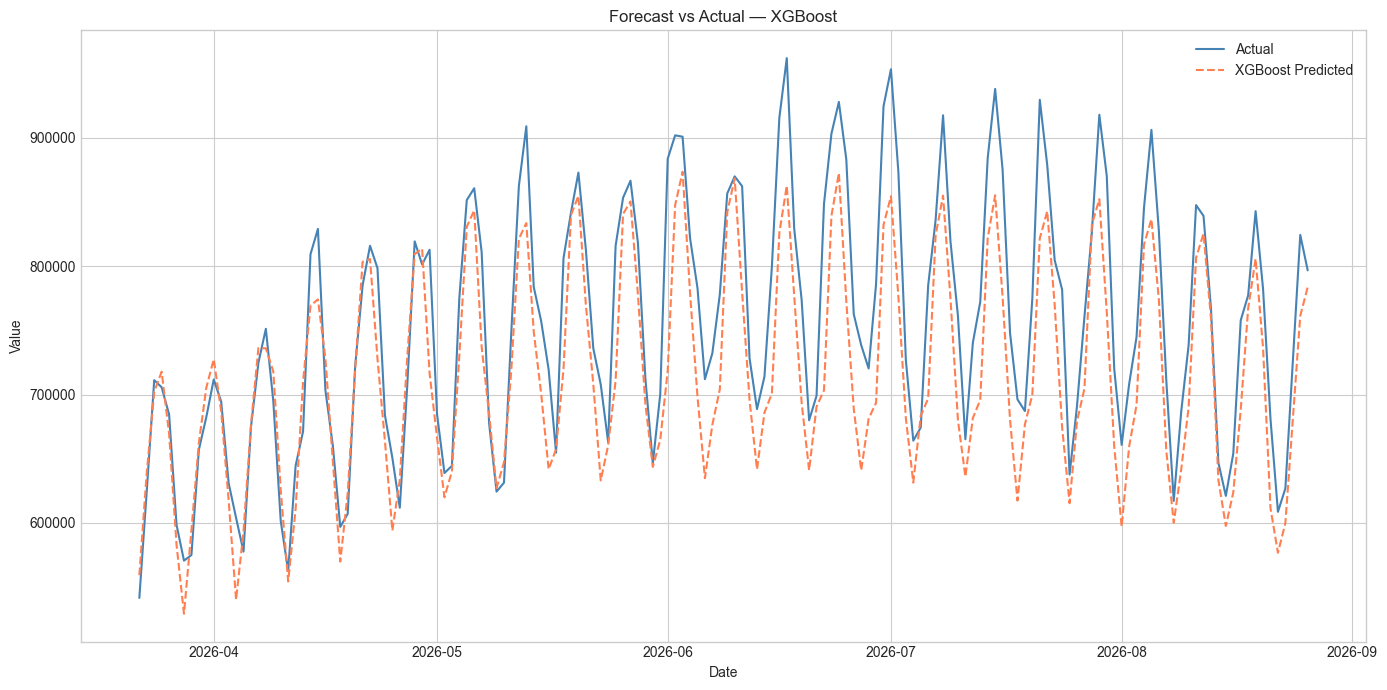

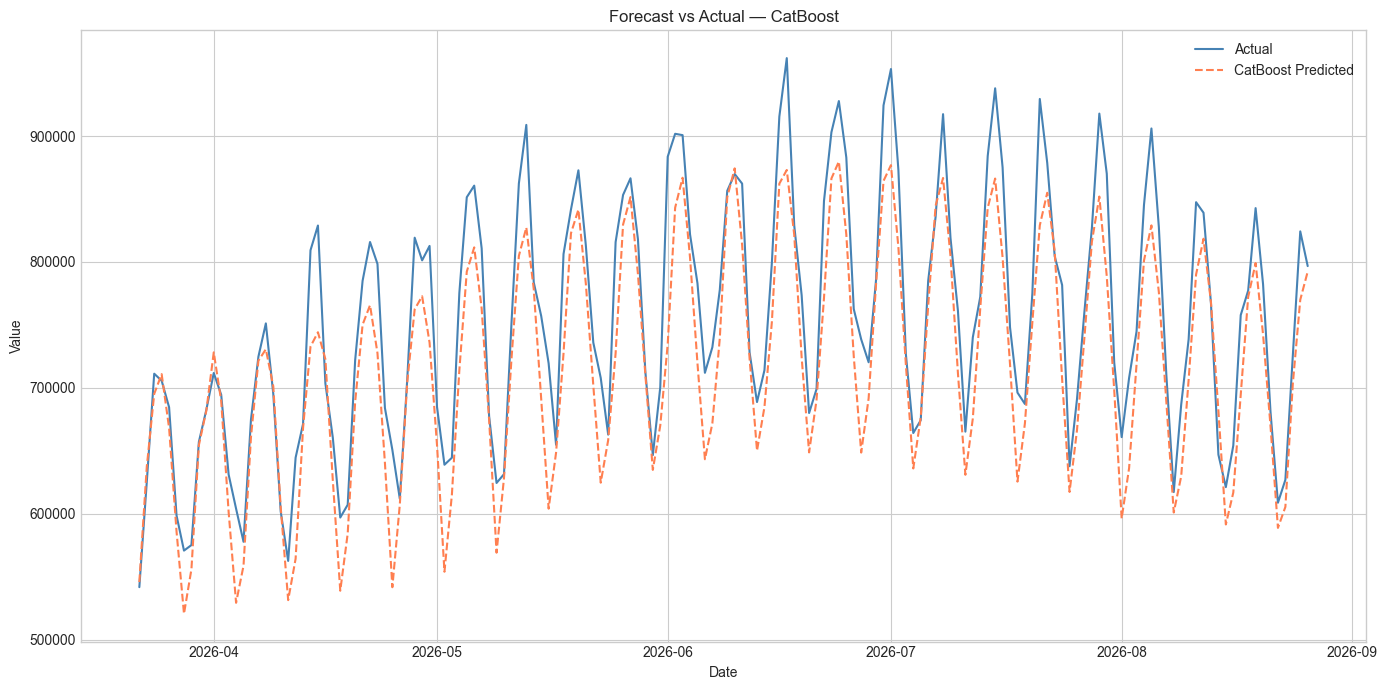

In [27]:
# Visualize ML forecasts (recursive multi-step)
for name, preds in [("LightGBM", lgbm_preds), ("XGBoost", xgb_preds), ("CatBoost", cat_preds)]:
    fig = eval_viz.plot_forecast(actuals_test, preds, dates=test_dates, model_name=name)
    plt.show()

---
## Section 6: Deep Learning Models

**Módulo `models/dl/`**

| Modelo | Enfoque | Veredicto honesto |
|---|---|---|
| **PatchTST** | Transformer: corta la historia en parches de 16 días y usa *atención* para relacionarlos; entrenado con split temporal interno (early stopping) y evaluado con pronóstico multi-ventana recursivo desde el contexto observado | Prometedor, pero con ~900 días de UNA serie tiene pocos ejemplos para aprender; los transformers brillan con big data |
| **TimesFM** | Modelo fundacional de Google pre-entrenado con millones de series ajenas (zero-shot) | **Excluido en Windows** (requiere JAX/lingvo, solo Linux). Ejecutar su fallback naive y llamarlo "TimesFM" sería inflar resultados — se reporta la ausencia en su lugar |

**Lección de especialista**: la complejidad se gana con datos, no se presupone. Con series cortas, un modelo bien especificado (Prophet) suele superar a una red neuronal con millones de parámetros.

In [28]:
# --- TimesFM: availability check (honest exclusion) ---
try:
    import timesfm  # noqa: F401
    TIMESFM_AVAILABLE = True
    print("TimesFM available.")
except ImportError:
    TIMESFM_AVAILABLE = False
    print("TimesFM NOT available on this platform (requires Linux/JAX).")
    print("Excluded from the comparison — running its naive fallback under the")
    print("name 'TimesFM' would produce misleading numbers.")

TimesFM NOT available on this platform (requires Linux/JAX).
Excluded from the comparison — running its naive fallback under the
name 'TimesFM' would produce misleading numbers.


In [29]:
# --- PatchTST ---
print("Training PatchTST (internal temporal split for early stopping)...")
pt_cfg = CONFIG["models"]["dl"]["patchtst"]
patchtst = PatchTSTForecaster(
    patch_len=pt_cfg["patch_len"], stride=pt_cfg["stride"],
    d_model=pt_cfg["d_model"], n_heads=pt_cfg["n_heads"],
    n_layers=pt_cfg["n_layers"], epochs=pt_cfg["epochs"],
    batch_size=pt_cfg["batch_size"], patience=pt_cfg["patience"],
    context_len=256, horizon=30,
)
n_val_pt = max(60, int(len(history_eval) * 0.10))
patchtst.fit(history_eval.iloc[:-n_val_pt], target_col=target_col, date_col="date",
             val_df=history_eval.iloc[-n_val_pt:])
patchtst_result = patchtst.predict(
    test_df, target_col=target_col, date_col="date", context_df=history_eval
)
print(f"PatchTST: {len(patchtst_result.predictions)} recursive multi-window predictions")

Training PatchTST (internal temporal split for early stopping)...


src.forecasting.models.dl.patchtst_model - INFO - Early stopping at epoch 9


src.forecasting.models.dl.patchtst_model - INFO - PatchTST fitted in 3.46 sec.


PatchTST: 158 recursive multi-window predictions


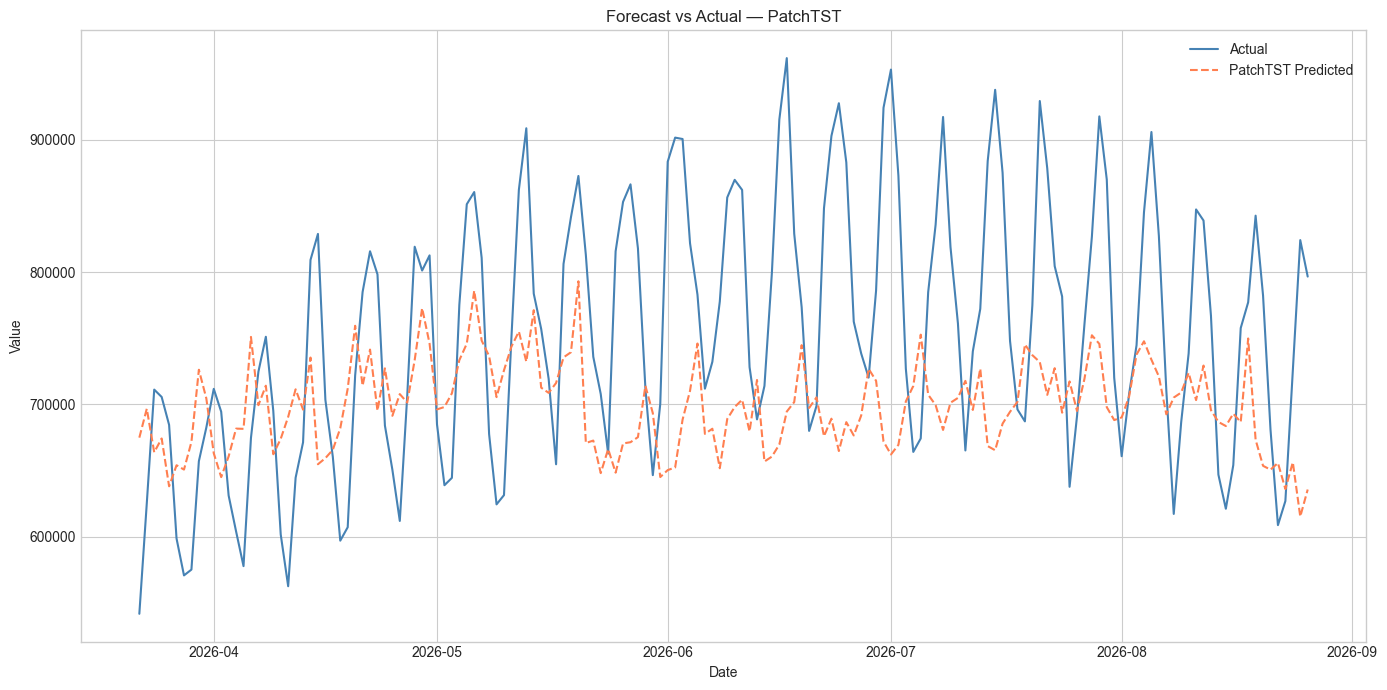

In [30]:
# Visualize DL forecasts (PatchTST; TimesFM excluded on this platform)
fig = eval_viz.plot_forecast(
    actuals_test, patchtst_result.predictions, dates=test_dates,
    model_name="PatchTST",
)
plt.show()

---
## Section 7: Final Comparison & Evaluation

**Módulo `evaluation/` — cómo leer la tabla correctamente**

**Guía de métricas:**
- **MAE** ($): error diario promedio — el lenguaje del negocio.
- **RMSE** ($): castiga los errores grandes; si RMSE >> MAE, hay días puntuales de desvío severo.
- **MAPE / sMAPE** (%): error porcentual por día, robusto a la escala.
- **WAPE** (%): error total ÷ ingreso total → "de cada $100 que entraron, me equivoqué en $X".
- **MASE**: error ÷ error del naive estacional. **El juez más justo**: <1 supera al baseline; comparable entre series de cualquier escala.

**Rigor estadístico aplicado:**
- Todos los modelos sobre la **misma serie y la misma ventana** (158 días) — comparación válida, sin manzanas con naranjas.
- **Diebold-Mariano con varianza Newey-West (h=7)**: prueba si la diferencia entre modelos es real o ruido; la corrección HAC compensa la autocorrelación natural de errores multi-paso (sin ella, los p-values serían falsamente significativos).
- **Diagnóstico de residuales del ganador**: Ljung-Box (si p es alto, los residuos no tienen autocorrelación → el modelo extrajo la información disponible), Jarque-Bera (normalidad), Breusch-Pagan (varianza constante del error).
- Baseline incluido en la tabla: **cada modelo debe justificar su existencia contra el SeasonalNaive**.

In [31]:
# Evaluate all models on the SAME series and window
evaluator = Evaluator()

all_results = {
    "SeasonalNaive": (actuals_test, naive_preds),
    "Prophet": (actuals_test, prophet_result.predictions),
    "SARIMAX": (actuals_test, sarimax_result.predictions),
    "ETS": (actuals_test, ets_result.predictions),
    "LightGBM": (actuals_test, lgbm_preds),
    "XGBoost": (actuals_test, xgb_preds),
    "CatBoost": (actuals_test, cat_preds),
    "PatchTST": (actuals_test, patchtst_result.predictions),
}

# MASE denominator: seasonal naive forecast on the same window
metrics_results = evaluator.compute_all_metrics(
    all_results, split="test", naive_forecast=naive_preds
)
comparison_df = evaluator.comparison_table(metrics_results)
print("=== Model Comparison — Test Set (multi-step, real $) ===")
display(comparison_df.round(2))

src.forecasting.evaluation.evaluator - INFO - SeasonalNaive (test): MAE=140666.10, RMSE=153303.54, MAPE=18.26%, WAPE=18.67%


src.forecasting.evaluation.evaluator - INFO - Prophet (test): MAE=26247.47, RMSE=34070.31, MAPE=3.38%, WAPE=3.48%


src.forecasting.evaluation.evaluator - INFO - SARIMAX (test): MAE=152221.35, RMSE=166126.29, MAPE=19.51%, WAPE=20.20%


src.forecasting.evaluation.evaluator - INFO - ETS (test): MAE=85750.11, RMSE=122344.92, MAPE=11.34%, WAPE=11.38%


src.forecasting.evaluation.evaluator - INFO - LightGBM (test): MAE=35669.30, RMSE=44957.63, MAPE=4.65%, WAPE=4.73%


src.forecasting.evaluation.evaluator - INFO - XGBoost (test): MAE=43439.53, RMSE=54190.11, MAPE=5.59%, WAPE=5.77%


src.forecasting.evaluation.evaluator - INFO - CatBoost (test): MAE=37949.30, RMSE=47376.01, MAPE=4.96%, WAPE=5.04%


src.forecasting.evaluation.evaluator - INFO - PatchTST (test): MAE=89133.54, RMSE=112393.18, MAPE=11.30%, WAPE=11.83%


=== Model Comparison — Test Set (multi-step, real $) ===


,N,MAE,RMSE,MAPE,sMAPE,MASE,WAPE
Model,,,,,,,
SeasonalNaive,158,140666.10,153303.54,18.26,20.42,1.00,18.67
Prophet,158,26247.47,34070.31,3.38,3.43,0.19,3.48
SARIMAX,158,152221.35,166126.29,19.52,21.94,1.08,20.20
ETS,158,85750.11,122344.92,11.34,10.23,0.61,11.38
LightGBM,158,35669.30,44957.63,4.65,4.81,0.25,4.73
XGBoost,158,43439.53,54190.11,5.59,5.82,0.31,5.77
CatBoost,158,37949.30,47376.01,4.96,5.15,0.27,5.04
PatchTST,158,89133.54,112393.18,11.30,11.98,0.63,11.83


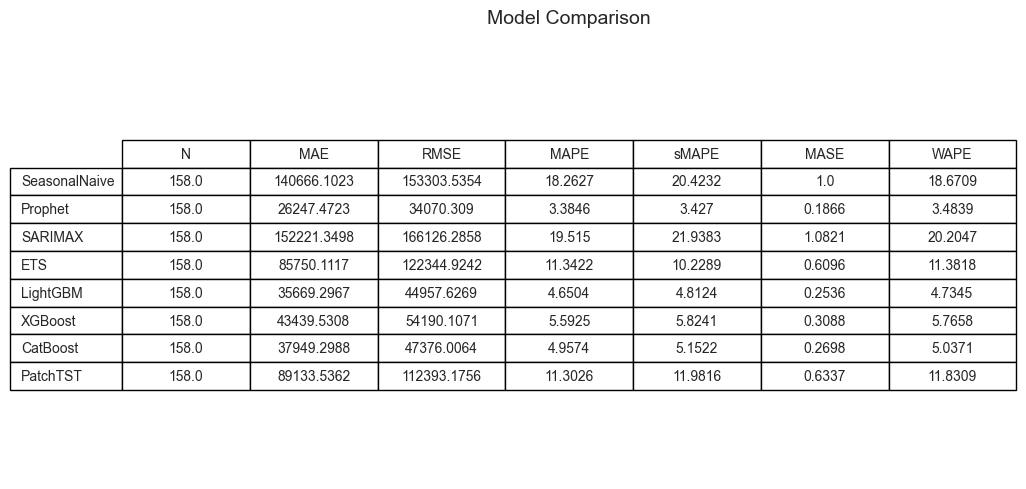

In [32]:
# Comparison visualization
fig = eval_viz.plot_comparison_table(comparison_df)
plt.show()

In [33]:
# Rank models by primary metric
comparison = evaluator.compare_models(metrics_results, primary_metric='MAE')
print(f"\nBest model (by MAE): {comparison.best_model}")
print(f"\nRankings by MAE: {comparison.rankings.get('MAE', [])}")

src.forecasting.evaluation.evaluator - INFO - Best model by MAE: Prophet



Best model (by MAE): Prophet

Rankings by MAE: ['Prophet', 'LightGBM', 'CatBoost', 'XGBoost', 'ETS', 'PatchTST', 'SeasonalNaive', 'SARIMAX']


In [34]:
# Diebold-Mariano: best model vs each competitor.
# h=7 (Newey-West lags) accounts for autocorrelated multi-step errors.
ranked = comparison.rankings.get("MAE", [])
model_a = ranked[0]
print(f"DM tests (best by MAE): {model_a} vs each competitor")

dm_rows = []
for other in ranked[1:]:
    dm = evaluator.diebold_mariano_test(
        actuals_test, all_results[model_a][1], all_results[other][1], h=7, power=1
    )
    dm_rows.append({
        "Competitor": other,
        "DM": dm["dm_statistic"],
        "p-value": dm["p_value"],
        "Better & significant": bool(dm["significant"] and dm["dm_statistic"] < 0),
    })
dm_df = pd.DataFrame(dm_rows).set_index("Competitor")
display(dm_df)

src.forecasting.evaluation.evaluator - INFO - DM test: stat=-4.1204, p=0.0001 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-6.6121, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.6044, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-3.4325, p=0.0008 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-12.5239, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-11.6568, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-12.7891, p=0.0000 — Significant


DM tests (best by MAE): Prophet vs each competitor


,DM,p-value,Better & significant
Competitor,,,
LightGBM,-4.1204,0.0001,True
CatBoost,-6.6121,0.0000,True
XGBoost,-5.6044,0.0000,True
ETS,-3.4325,0.0008,True
PatchTST,-12.5239,0.0000,True
SeasonalNaive,-11.6568,0.0000,True
SARIMAX,-12.7891,0.0000,True


In [35]:
# Residual diagnostics for best model
best_name = comparison.best_model
actuals_best, preds_best = all_results[best_name]
diag = evaluator.residual_diagnostics(actuals_best, preds_best)
print(f"\nResidual Diagnostics — {best_name}:")
for test_name, result in diag.items():
    print(f"  {test_name}: {result}")

src.forecasting.evaluation.evaluator - INFO - Residual diagnostics: JB p=0.1665, LB min_p=0.0000



Residual Diagnostics — Prophet:
  jarque_bera: {'statistic': 3.5853, 'p_value': 0.1665}
  ljung_box: {'min_p_value': 0.0}
  breusch_pagan: {'statistic': 3.1002, 'p_value': 0.0783}
  residual_mean: 11778.5368
  residual_std: 31969.5484


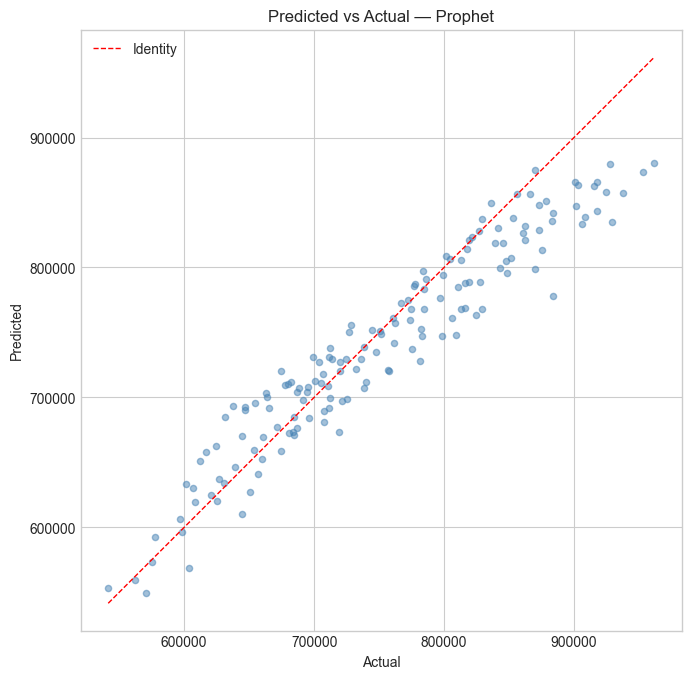

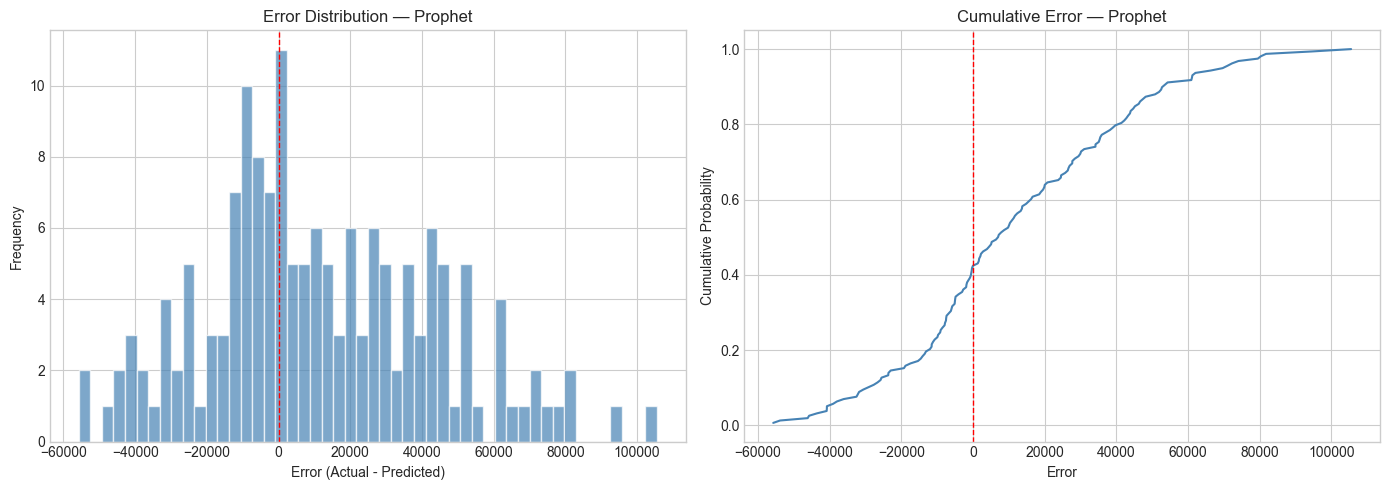

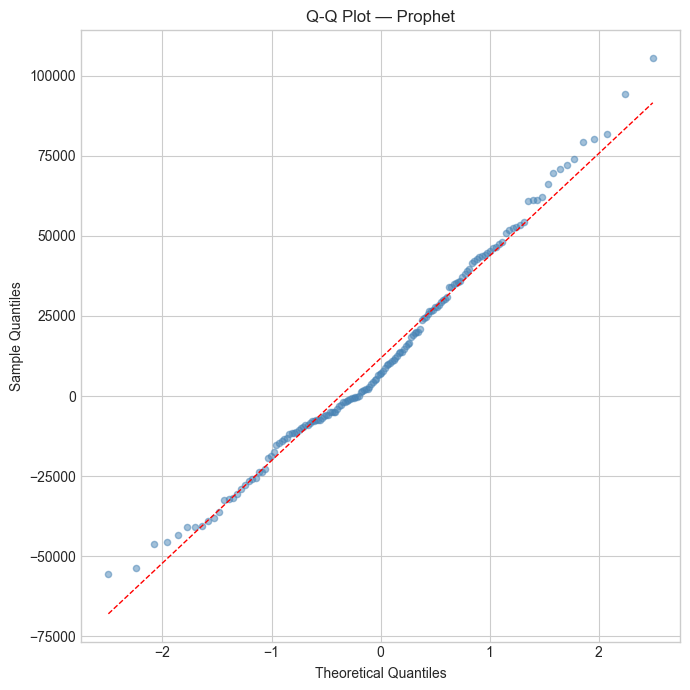

In [36]:
# Scatter and error distribution for best model
fig = eval_viz.plot_scatter(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_error_distribution(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_qq(actuals_best, preds_best, model_name=best_name)
plt.show()

---
## Section 8: Future Forecast

**Práctica estándar post-selección**: el modelo ganador se **reentrena con TODA la historia observada** (train+val+test) — en producción no se desaprovecha el 30% más reciente de los datos — y pronostica los próximos 90 días con la misma mecánica honesta de la evaluación (recursiva para ML, componentes nativos para Prophet).

**Cómo leer el pronóstico:**
- El valor central es la **mediana esperada** del ingreso diario; la banda del 95% CI no es "el rango donde seguro caerá": es la incertidumbre estimada del modelo.
- La incertidumbre **crece con el horizonte**: la primera semana es mucho más fiable que el tercer mes.
- Suposición clave (y frágil): los patrones históricos — tendencia, estacionalidad, festivos — continúan; un choque externo (evento, crisis, cambio regulatorio) invalida el pronóstico y exige reentrenar.

In [37]:
# ------------------------------------------------------------------
# FUTURE FORECAST: best model retrained on ALL observed data
# ------------------------------------------------------------------
horizon = CONFIG["forecasting"]["horizon_days"]
last_observed = full_history["date"].max()
future_dates = pd.date_range(last_observed + pd.Timedelta(days=1), periods=horizon, freq="D")
future_df = pd.DataFrame({"date": future_dates})

print(f"Best model: {best_name} | Forecasting {horizon} days from {future_dates[0].date()}")

future_lo = future_hi = None

gbm_map = {"LightGBM": lgbm, "XGBoost": xgb, "CatBoost": cat}

if best_name in gbm_map:
    model_obj = gbm_map[best_name]
    full_feat = pipeline.feature_engineer.transform(full_history)
    full_feat = pipeline.holiday_engineer.transform(full_feat)
    full_feat = pipeline.outlier_handler.transform(full_feat)
    model_obj.final_refit(full_feat, target_col=target_col, date_col="date",
                          feature_cols=feature_cols_ml)
    future_preds = recursive_forecast(
        model_obj, full_history[["date", target_col]], future_dates,
        target_col=target_col, date_col="date",
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
    )
elif best_name == "SeasonalNaive":
    last_week_full = full_history[target_col].values[-7:]
    future_preds = np.array([last_week_full[i % 7] for i in range(horizon)])
elif best_name == "Prophet":
    final_model = ProphetForecaster(
        changepoint_prior_scale=CONFIG["models"]["statistical"]["prophet"]["changepoint_prior_scale"],
        seasonality_prior_scale=CONFIG["models"]["statistical"]["prophet"]["seasonality_prior_scale"],
    )
    final_model.fit(full_history, target_col=target_col, date_col="date")
    fr = final_model.predict(future_df, target_col=target_col, date_col="date")
    future_preds, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == "SARIMAX":
    final_model = SARIMAXForecaster(
        seasonal_periods=CONFIG["models"]["statistical"]["sarimax"]["seasonal_periods"],
        stepwise=CONFIG["models"]["statistical"]["sarimax"]["stepwise"],
    )
    final_model.fit(full_history, target_col=target_col, date_col="date")
    fr = final_model.predict(future_df, target_col=target_col, date_col="date")
    future_preds, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == "ETS":
    final_model = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
    final_model.fit(full_history, target_col=target_col, date_col="date")
    fr = final_model.predict(future_df, target_col=target_col, date_col="date")
    future_preds, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == "PatchTST":
    final_model = PatchTSTForecaster(
        patch_len=pt_cfg["patch_len"], stride=pt_cfg["stride"],
        d_model=pt_cfg["d_model"], n_heads=pt_cfg["n_heads"],
        n_layers=pt_cfg["n_layers"], epochs=pt_cfg["epochs"],
        batch_size=pt_cfg["batch_size"], patience=pt_cfg["patience"],
        context_len=256, horizon=30,
    )
    n_val_f = max(60, int(len(full_history) * 0.10))
    final_model.fit(full_history.iloc[:-n_val_f], target_col=target_col,
                    date_col="date", val_df=full_history.iloc[-n_val_f:])
    fr = final_model.predict(future_df, target_col=target_col, date_col="date",
                             context_df=full_history)
    future_preds = fr.predictions

print(f"\nTotal forecasted revenue ({horizon}d): ${np.sum(future_preds):,.0f}")
print(f"Daily mean: ${np.mean(future_preds):,.0f}")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmp602wog5n\1w4gimjx.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmp602wog5n\g3qnqms7.json


cmdstanpy - DEBUG - idx 0


...

Best model: Prophet | Forecasting 90 days from 2026-08-27


14:31:03 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.23 seconds on 1095 rows.



Total forecasted revenue (90d): $52,299,204
Daily mean: $581,102


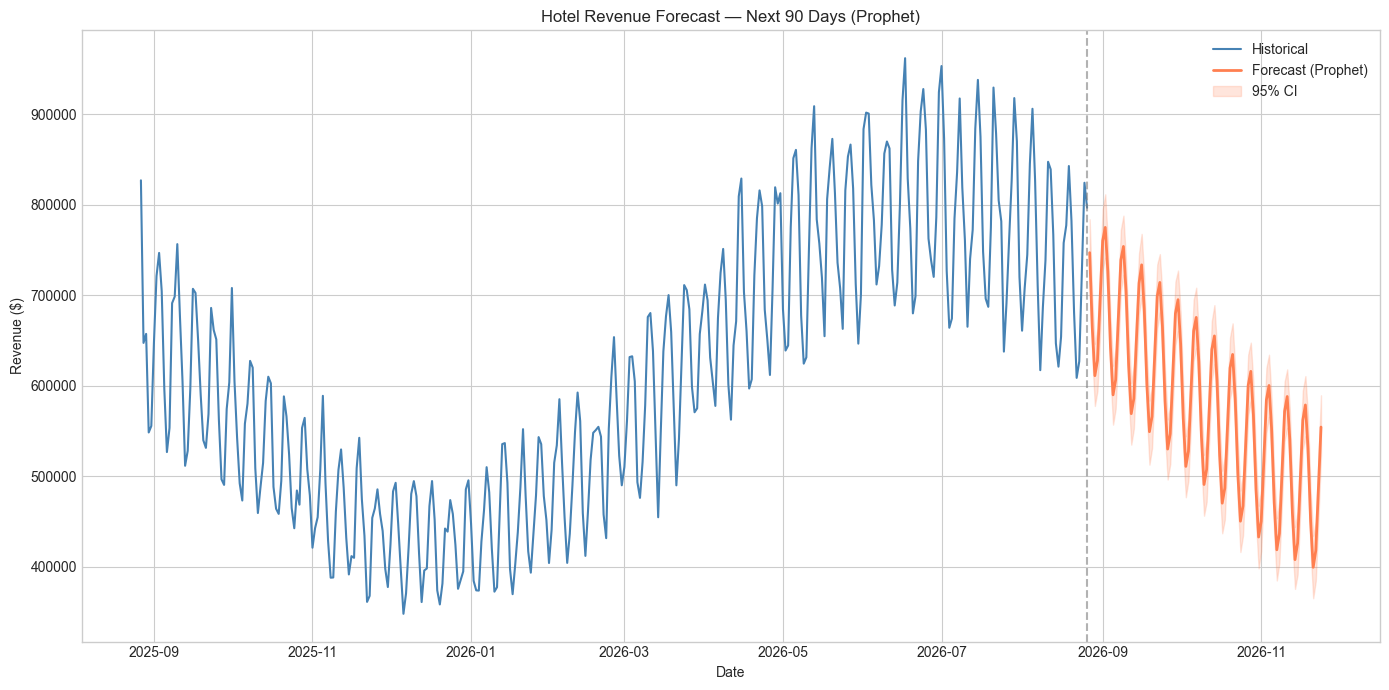

In [38]:
# Plot future forecast
fig, ax = plt.subplots(figsize=(14, 7))
hist_plot = full_history.iloc[-365:]
ax.plot(hist_plot["date"], hist_plot[target_col], label="Historical", color="steelblue", linewidth=1.5)
ax.plot(future_dates, future_preds, label=f"Forecast ({best_name})", color="coral", linewidth=2)
if future_lo is not None:
    ax.fill_between(future_dates, future_lo, future_hi, alpha=0.2, color="coral", label="95% CI")
ax.axvline(x=last_observed, color="gray", linestyle="--", alpha=0.6)
ax.set_title(f"Hotel Revenue Forecast — Next {horizon} Days ({best_name})")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue ($)")
ax.legend()
fig.tight_layout()
plt.show()

In [39]:
# Assumptions & Limitations (honest reporting)
print("=== Supuestos ===")
assumptions = [
    "Los patrones históricos (tendencia, estacionalidad, festivos CR) continúan.",
    "Sin choques externos mayores (pandemias, desastres naturales).",
    "La operación hotelera se mantiene consistente con los datos observados.",
]
for i, a in enumerate(assumptions, 1):
    print(f"  {i}. {a}")

print("\n=== Limitaciones ===")
limitations = [
    "Datos sintéticos: las cifras validan la metodología, no son números de negocio.",
    "La incertidumbre crece con el horizonte (90 días es exigente).",
    "Sin datos exógenos (clima, eventos, precios de competencia).",
    "Intervalos de confianza aproximados (basados en residuales).",
    "Reentrenar periódicamente con datos nuevos y monitorear el error.",
]
for i, l in enumerate(limitations, 1):
    print(f"  {i}. {l}")


=== Supuestos ===
  1. Los patrones históricos (tendencia, estacionalidad, festivos CR) continúan.
  2. Sin choques externos mayores (pandemias, desastres naturales).
  3. La operación hotelera se mantiene consistente con los datos observados.

=== Limitaciones ===
  1. Datos sintéticos: las cifras validan la metodología, no son números de negocio.
  2. La incertidumbre crece con el horizonte (90 días es exigente).
  3. Sin datos exógenos (clima, eventos, precios de competencia).
  4. Intervalos de confianza aproximados (basados en residuales).
  5. Reentrenar periódicamente con datos nuevos y monitorear el error.


---
## Section 9: Conclusions

**Marco de decisión aplicado (reproducible para cualquier serie nueva):**
1. **¿Supera el naive?** MASE < 1 es requisito mínimo; MASE < 0.5 es señal fuerte de valor.
2. **¿La ventaja es estadísticamente real?** Diebold-Mariano con corrección Newey-West, no "el que tenga el número más bajo".
3. **¿Es utilizable por el negocio?** En hotelería, un WAPE < 10% en horizontes trimestrales suele bastar para planificar ingresos, inventario y personal.
4. **¿Es sostenible en el tiempo?** Los patrones cambian: monitorear el error periódicamente y reentrenar con cada dato nuevo.

**Honestidad como política de reporte**: datos sintéticos declarados, TimesFM excluido en vez de fingido, SARIMAX reportado fallando bajo el naive, advertencias visibles junto a las cifras. La credibilidad del pronóstico vale más que una tabla bonita — un forecast que el negocio no puede auditar es un forecast que el negocio no va a usar.

In [40]:
best_row = comparison_df.loc[best_name]
naive_row = comparison_df.loc["SeasonalNaive"]
improvement = (1 - best_row["MAE"] / naive_row["MAE"]) * 100

print("=" * 64)
print("        CONCLUSIONES (protocolo honesto multi-paso)")
print("=" * 64)
print(f"\n1. MODELO GANADOR (MAE en test): {best_name}")
print(f"   MAE: ${best_row['MAE']:,.0f} | RMSE: ${best_row['RMSE']:,.0f} | WAPE: {best_row['WAPE']:.1f}%")
print(f"   MASE: {best_row['MASE']:.2f}  (<1 significa que supera al seasonal naive)")
print(f"   Mejora vs SeasonalNaive (MAE): {improvement:.1f}%")
try:
    sig = dm_df[dm_df["Better & significant"]]
    print(f"\n2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):")
    print(f"   {best_name} supera significativamente a: {list(sig.index) if len(sig) else 'ninguno (p>=0.05)'}")
except Exception:
    pass
print(f"\n3. PRONOSTICO {horizon} DIAS (mejor modelo reentrenado con TODA la historia):")
print(f"   Total: ${np.sum(future_preds):,.0f}  |  Media diaria: ${np.mean(future_preds):,.0f}")
print(f"\n4. ADVERTENCIAS HONESTAS:")
print("   - Datos SINTETICOS (5 hoteles generados): las cifras validan la")
print("     metodologia; conecte el SQL real para numeros de negocio.")
print("   - Metricas multi-paso reales: los reales del test jamas se usaron")
print("     como entradas de los modelos ML.")
print("   - La incertidumbre crece con el horizonte; reentrenar periodicamente.")
print("   - Sin datos exogenos (clima, eventos, precios de competencia).")
print("   - TimesFM excluido en Windows (requiere Linux/JAX).")
print("=" * 64)

        CONCLUSIONES (protocolo honesto multi-paso)

1. MODELO GANADOR (MAE en test): Prophet
   MAE: $26,247 | RMSE: $34,070 | WAPE: 3.5%
   MASE: 0.19  (<1 significa que supera al seasonal naive)
   Mejora vs SeasonalNaive (MAE): 81.3%

2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):
   Prophet supera significativamente a: ['LightGBM', 'CatBoost', 'XGBoost', 'ETS', 'PatchTST', 'SeasonalNaive', 'SARIMAX']

3. PRONOSTICO 90 DIAS (mejor modelo reentrenado con TODA la historia):
   Total: $52,299,204  |  Media diaria: $581,102

4. ADVERTENCIAS HONESTAS:
   - Datos SINTETICOS (5 hoteles generados): las cifras validan la
     metodologia; conecte el SQL real para numeros de negocio.
   - Metricas multi-paso reales: los reales del test jamas se usaron
     como entradas de los modelos ML.
   - La incertidumbre crece con el horizonte; reentrenar periodicamente.
   - Sin datos exogenos (clima, eventos, precios de competencia).
   - TimesFM excluido en Windows (requiere Linux/J